In [2]:
# Based on the information gathered, the Modi script has 48 distinct characters: 14 vowels and 34 consonants, plus 10 digits and 14 vowel diacritics (matras).
# The script does not use spaces between words traditionally.
# We will generate a balanced text sample in English letters representing the Modi script characters and their combinations without spaces.

# Define the basic character sets based on the information:
vowels = ['a', 'aa', 'i', 'ii', 'u', 'uu', 'e', 'ai', 'o', 'au', 'am', 'ah', 'ar', 'al']  # 14 vowels
consonants = ['k', 'kh', 'g', 'gh', 'ng', 'c', 'ch', 'j', 'jh', 'ny', 't', 'th', 'd', 'dh', 'n', 'p', 'ph', 'b', 'bh', 'm', 'y', 'r', 'l', 'v', 'sh', 'ss', 's', 'h', 'l2', 'ksh', 'tr', 'gy', 'jny', 'shr', 'tra']  # 34 consonants
matras = ['a', 'aa', 'i', 'ii', 'u', 'uu', 'e', 'ai', 'o', 'au', 'am', 'ah', 'ar', 'al']  # same as vowels for matras

digits = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# Generate combinations of consonants with matras
combinations = []
for c in consonants:
    for m in matras:
        combinations.append(c + m)

# Generate a text sample by concatenating vowels, consonants, combinations, and digits without spaces
text_sample = ''

# Add vowels
text_sample += ''.join(vowels)

# Add consonants
text_sample += ''.join(consonants)

# Add consonant+matra combinations
text_sample += ''.join(combinations)

# Add digits
text_sample += ''.join(digits)

# Repeat the text sample to reach approximately 5000 words (assuming average word length ~5 characters, no spaces)
# 5000 words * 5 chars = 25000 characters approx
repeat_factor = 25000 // len(text_sample) + 1
final_text = text_sample * repeat_factor

# Trim to exact length
final_text = final_text[:25000]

# Output the length and a preview of the generated text
len(final_text), final_text

(25000,
 '...')

In [3]:
pip install aspose-words opencv-python


Note: you may need to restart the kernel to use updated packages.Collecting aspose-words
   ---------------------------------------- 0.0/67.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/67.4 MB ? eta -:--:--
   -- ------------------------------------- 3.4/67.4 MB 13.4 MB/s eta 0:00:05
   ---- ----------------------------------- 7.1/67.4 MB 15.6 MB/s eta 0:00:04
   ------ --------------------------------- 11.5/67.4 MB 17.2 MB/s eta 0:00:04
   --------- ------------------------------ 15.7/67.4 MB 18.0 MB/s eta 0:00:03
   ----------- ---------------------------- 20.2/67.4 MB 18.8 MB/s eta 0:00:03
   -------------- ------------------------- 24.6/67.4 MB 19.0 MB/s eta 0:00:03
   ----------------- ---------------------- 29.1/67.4 MB 19.2 MB/s eta 0:00:02
   -------------------- ------------------- 33.8/67.4 MB 19.5 MB/s eta 0:00:02
   ---------------------- ----------------- 38.3/67.4 MB 19.8 MB/s eta 0:00:02
   ------------------------- -------------- 42.5/67.4 MB 19.9 


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import aspose.words as aw
import cv2
import numpy as np

def get_modi_bboxes(doc_path):
    # Convert Word document to in-memory image
    doc = aw.Document(doc_path)
    options = aw.saving.ImageSaveOptions(aw.SaveFormat.PNG)
    options.resolution = 300  # High resolution for accurate segmentation
    options.paper_color = aw.Color(255, 255, 255)  # Force white background
    
    # Convert first page to memory buffer
    stream = aw.io.MemoryStream()
    options.page_set = aw.saving.PageSet(0)
    doc.save(stream, options)
    
    # Process image buffer with OpenCV
    nparr = np.frombuffer(stream.to_array(), np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)
    
    # Modi-specific segmentation (vertical projection profile)
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    vertical_proj = np.sum(thresh, axis=0)
    
    # Find character boundaries [1][2]
    bboxes = []
    start = None
    for idx, val in enumerate(vertical_proj):
        if val > 0 and start is None:
            start = idx
        elif val == 0 and start is not None:
            bboxes.append((start, 0, idx-start, img.shape[0]))
            start = None
    
    return bboxes

# Usage
bounding_boxes = get_modi_bboxes("dlcv_modi.docx")
print(f"Detected {len(bounding_boxes)} Modi characters")


AttributeError: 'aspose.words.saving.ImageSaveOptions' object has no attribute 'resolution'

In [8]:
import aspose.words as aw
import cv2
import numpy as np
import io  # Import the built-in io module

def get_modi_bboxes(doc_path):
    # Load the Word document
    doc = aw.Document(doc_path)
    
    # Set image save options with correct resolution properties
    options = aw.saving.ImageSaveOptions(aw.SaveFormat.PNG)
    options.horizontal_resolution = 300  # DPI for good quality
    options.vertical_resolution = 300
    options.page_set = aw.saving.PageSet(0)  # Process only first page
    
    # Save first page to in-memory stream as PNG
    stream = io.BytesIO()
    doc.save(stream, options)
    stream.seek(0)  # Reset stream position to the beginning
    
    # Convert stream buffer to numpy array for OpenCV
    img_array = np.frombuffer(stream.read(), np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
    
    # Binarize image (invert for Modi script - black text on white)
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    
    # Vertical projection profile for segmentation
    vertical_proj = np.sum(thresh, axis=0)
    
    # Detect character boundaries based on vertical projection
    bboxes = []
    start = None
    for idx, val in enumerate(vertical_proj):
        if val > 0 and start is None:
            start = idx
        elif val == 0 and start is not None:
            # Bounding box: (x, y, width, height)
            bboxes.append((start, 0, idx - start, img.shape[0]))
            start = None
    # Handle last character if line ends without zero column
    if start is not None:
        bboxes.append((start, 0, len(vertical_proj) - start, img.shape[0]))
    
    return bboxes

if __name__ == "__main__":
    docx_path = "dlcv_modi.docx"  # Replace with your file path
    boxes = get_modi_bboxes(docx_path)
    print(f"Detected {len(boxes)} Modi characters with bounding boxes:")
    for i, box in enumerate(boxes, 1):
        print(f"Char {i}: x={box[0]}, y={box[1]}, width={box[2]}, height={box[3]}")


Detected 1 Modi characters with bounding boxes:
Char 1: x=294, y=0, width=1897, height=3508


In [9]:
import aspose.words as aw
import cv2
import numpy as np
import io

def remove_shirorekha(thresh_img):
    # Define a horizontal kernel to detect the top line (shirorekha)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (100, 1))
    horizontal_lines = cv2.morphologyEx(thresh_img, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Remove the top line from the image
    cleaned = cv2.subtract(thresh_img, horizontal_lines)
    return cleaned

def get_modi_bboxes(doc_path):
    # Load the Word document
    doc = aw.Document(doc_path)
    
    # Save options
    options = aw.saving.ImageSaveOptions(aw.SaveFormat.PNG)
    options.horizontal_resolution = 300
    options.vertical_resolution = 300
    options.page_set = aw.saving.PageSet(0)  # First page only
    
    # Save page to memory stream
    stream = io.BytesIO()
    doc.save(stream, options)
    
    # Convert to numpy image
    img_array = np.frombuffer(stream.getvalue(), np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
    
    # Threshold (invert: black text on white becomes white on black)
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

    # Remove shirorekha
    cleaned = remove_shirorekha(thresh)

    # Vertical projection for character segmentation
    vertical_proj = np.sum(cleaned, axis=0)
    
    # Bounding box extraction based on projection
    bboxes = []
    start = None
    for idx, val in enumerate(vertical_proj):
        if val > 0 and start is None:
            start = idx
        elif val == 0 and start is not None:
            bboxes.append((start, 0, idx - start, img.shape[0]))
            start = None
    if start is not None:
        bboxes.append((start, 0, len(vertical_proj) - start, img.shape[0]))

    return bboxes, img, cleaned

if __name__ == "__main__":
    docx_path = "dlcv_modi.docx"
    boxes, original_img, cleaned_img = get_modi_bboxes(docx_path)

    print(f"Detected {len(boxes)} characters:")
    for i, box in enumerate(boxes, 1):
        x, y, w, h = box
        print(f"Char {i}: x={x}, y={y}, width={w}, height={h}")

    # Optional: visualize the boxes
    vis = cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR)
    for x, y, w, h in boxes:
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 0, 255), 1)
    cv2.imshow("Segmented Characters", vis)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Detected 1 characters:
Char 1: x=294, y=0, width=1887, height=3508


In [10]:
pip install opencv-python pytesseract pillow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
!pip install docx2pdf



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
!pip install pdf2image



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
convert("dlcv_modi.docx", "dlcv_modi.pdf")


In [ ]:
from docx2pdf import convert
from pdf2image import convert_from_path

# First, convert DOCX to PDF (optional - if direct image not available)
convert("dlcv_modi.docx")  # Creates dlcv_modi.pdf

# Then convert PDF to images
pages = convert_from_path("dlcv_modi.pdf")
for i, page in enumerate(pages):
    page.save(f"page_{i}.png", "PNG")


  0%|          | 0/1 [00:00<?, ?it/s]

com_error: (-2147352567, 'Exception occurred.', (0, 'Microsoft Word', 'You cannot close Microsoft Word because a dialog box is open.\nClick OK, switch to Word, and then close the dialog box.', 'wdmain11.chm', 24959, -2146822809), None)

In [2]:
import cv2
import numpy as np

# Load image
img = cv2.imread("dlcv.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Binarize image
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remove horizontal lines
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
detected_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
line_removed = cv2.subtract(binary, detected_lines)

# Optional: dilate to reconnect broken letters
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
processed = cv2.dilate(line_removed, kernel, iterations=1)

# Find contours (individual characters)
contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Store bounding boxes as (x, y, w, h)
bounding_boxes = []

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > 5 and h > 10:  # Filter out small noise
        bounding_boxes.append((x, y, w, h))

# Optional: sort boxes left-to-right
bounding_boxes = sorted(bounding_boxes, key=lambda box: box[0])

# Print the boxes
print(f"Detected {len(bounding_boxes)} character bounding boxes:")
for i, (x, y, w, h) in enumerate(bounding_boxes):
    print(f"Char {i+1}: x={x}, y={y}, width={w}, height={h}")


Detected 290 character bounding boxes:
Char 1: x=40, y=363, width=12, height=20
Char 2: x=40, y=177, width=28, height=20
Char 3: x=41, y=479, width=14, height=14
Char 4: x=42, y=553, width=14, height=14
Char 5: x=42, y=516, width=28, height=20
Char 6: x=42, y=442, width=25, height=14
Char 7: x=42, y=404, width=38, height=14
Char 8: x=42, y=330, width=17, height=20
Char 9: x=42, y=69, width=14, height=14
Char 10: x=43, y=293, width=13, height=14
Char 11: x=43, y=255, width=13, height=14
Char 12: x=43, y=218, width=17, height=14
Char 13: x=43, y=143, width=17, height=14
Char 14: x=43, y=106, width=77, height=15
Char 15: x=43, y=28, width=79, height=26
Char 16: x=51, y=363, width=31, height=20
Char 17: x=55, y=331, width=11, height=13
Char 18: x=56, y=480, width=13, height=13
Char 19: x=57, y=554, width=40, height=13
Char 20: x=57, y=256, width=6, height=13
Char 21: x=57, y=70, width=26, height=14
Char 22: x=58, y=294, width=12, height=13
Char 23: x=60, y=135, width=38, height=24
Char 24:

In [1]:
print("a")

a


In [4]:
import cv2
import numpy as np

# Load image
img = cv2.imread("dlcv.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Binarize image (invert so text is white)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# --- Detect and Remove Shirorekha ---
# Use a wide horizontal kernel to detect the top line (Shirorekha)
shirorekha_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (50, 1))
shirorekha = cv2.morphologyEx(binary, cv2.MORPH_OPEN, shirorekha_kernel, iterations=1)

# Optional: filter to keep only top-most lines
# You can erode slightly and mask with the original binary image to isolate the top lines
eroded_shirorekha = cv2.erode(shirorekha, None, iterations=1)
top_lines = cv2.bitwise_and(shirorekha, eroded_shirorekha)

# Remove detected Shirorekha from binary image
no_shirorekha = cv2.subtract(binary, top_lines)

# Continue processing
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
detected_lines = cv2.morphologyEx(no_shirorekha, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
line_removed = cv2.subtract(no_shirorekha, detected_lines)

# Optional: dilate to reconnect broken letters
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
processed = cv2.dilate(line_removed, kernel, iterations=1)

# Find contours (individual characters)
contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Store bounding boxes
bounding_boxes = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > 5 and h > 10:
        bounding_boxes.append((x, y, w, h))

# Sort left to right
bounding_boxes = sorted(bounding_boxes, key=lambda box: box[0])

# Visualize
visualized = img.copy()
for i, (x, y, w, h) in enumerate(bounding_boxes):
    cv2.rectangle(visualized, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(visualized, str(i+1), (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

cv2.imshow("Without Shirorekha", visualized)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [6]:
import cv2
import numpy as np

# Load and binarize image
img = cv2.imread("dlcv.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# --- Horizontal Projection Profile ---
horizontal_sum = np.sum(binary == 255, axis=1)  # Count white pixels row-wise
threshold = 0.7 * np.max(horizontal_sum)         # Dynamic threshold for Shirorekha

# Create a mask to remove rows likely to be Shirorekha
shirorekha_removed = binary.copy()
for row in range(len(horizontal_sum)):
    if horizontal_sum[row] > threshold:
        shirorekha_removed[row, :] = 0  # Remove the Shirorekha row

# Visualize the result (invert for display)
inverted_result = cv2.bitwise_not(shirorekha_removed)
cv2.imshow("Image without Shirorekha", inverted_result)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [11]:
import cv2
import numpy as np

# STEP 1: Load and binarize image
img = cv2.imread("dlcv.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# STEP 2: Remove Shirorekha using horizontal projection
horizontal_sum = np.sum(binary == 255, axis=1)
threshold = 0.7 * np.max(horizontal_sum)

shirorekha_removed = binary.copy()
for row in range(len(horizontal_sum)):
    if horizontal_sum[row] > threshold:
        shirorekha_removed[row, :] = 0

# STEP 3: Save intermediate image (invert to normal for viewing/segmentation)
shirorekha_removed_inverted = cv2.bitwise_not(shirorekha_removed)
cv2.imwrite("shirorekha_removed.png", shirorekha_removed_inverted)

# ----------------------------
# NEW STAGE: CHARACTER SEGMENTATION
# ----------------------------

# STEP 4: Reload the cleaned image
seg_img = cv2.imread("shirorekha_removed.png")
gray_seg = cv2.cvtColor(seg_img, cv2.COLOR_BGR2GRAY)
_, binary_seg = cv2.threshold(gray_seg, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# STEP 5: Clean horizontal lines (optional)
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
extra_lines = cv2.morphologyEx(binary_seg, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
line_cleaned = cv2.subtract(binary_seg, extra_lines)

# STEP 6: Dilate to reconnect characters
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
processed = cv2.dilate(line_cleaned, kernel, iterations=1)

# STEP 7: Find contours for characters
contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
bounding_boxes = []

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > 3 and h > 10:
        bounding_boxes.append((x, y, w, h))

# STEP 8: Sort and draw boxes
bounding_boxes = sorted(bounding_boxes, key=lambda box: box[0])
visualized = seg_img.copy()
for i, (x, y, w, h) in enumerate(bounding_boxes):
    cv2.rectangle(visualized, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(visualized, str(i + 1), (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

# STEP 9: Show final output
cv2.imshow("Final Character Segmentation", visualized)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [2]:
import cv2
import numpy as np

# STEP 1: Load and binarize image
img = cv2.imread("check.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# STEP 2: Remove Shirorekha using horizontal projection
horizontal_sum = np.sum(binary == 255, axis=1)
threshold = 0.7 * np.max(horizontal_sum)

shirorekha_removed = binary.copy()
for row in range(len(horizontal_sum)):
    if horizontal_sum[row] > threshold:
        shirorekha_removed[row, :] = 0

# STEP 3: Save intermediate image (invert to normal for viewing/segmentation)
shirorekha_removed_inverted = cv2.bitwise_not(shirorekha_removed)
cv2.imwrite("shirorekha_removed.png", shirorekha_removed_inverted)

True

In [3]:
# After removing shirorekha
# 1. Optional erosion to widen gaps
hgap_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 1))
gapped = cv2.erode(shirorekha_removed, hgap_kernel, iterations=1)

# 2. Optional horizontal stretching
h, w = gapped.shape
stretched = cv2.resize(gapped, (int(w * 2), h), interpolation=cv2.INTER_NEAREST)

# 3. Save and reload for segmentation
final_stretch = cv2.bitwise_not(stretched)
cv2.imwrite("gapped_image.png", final_stretch)


True

In [4]:
cv2.imshow("Horizontally Stretched Image", final_stretch)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [8]:

seg_img = cv2.imread("gapped_image.png")
gray_seg = cv2.cvtColor(seg_img, cv2.COLOR_BGR2GRAY)
_, binary_seg = cv2.threshold(gray_seg, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# STEP 5: Clean horizontal lines (optional)
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
extra_lines = cv2.morphologyEx(binary_seg, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
line_cleaned = cv2.subtract(binary_seg, extra_lines)

# STEP 6: Dilate to reconnect characters
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4))
processed = cv2.dilate(line_cleaned, kernel, iterations=1)

# STEP 7: Find contours for characters
contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
bounding_boxes = []

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > 10 and h > 10:
        bounding_boxes.append((x, y, w, h))

# STEP 8: Sort and draw boxes
bounding_boxes = sorted(bounding_boxes, key=lambda box: box[0])
visualized = seg_img.copy()
for i, (x, y, w, h) in enumerate(bounding_boxes):
    cv2.rectangle(visualized, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(visualized, str(i + 1), (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

# STEP 9: Show final output
cv2.imshow("Final Character Segmentation", visualized)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [11]:
import cv2
import numpy as np
import os
import pandas as pd

# Define input and output paths
input_folder = "D:\dlcv project\images"  # Folder where images are stored
output_folder = "./bounding_boxes_csv"  # Output folder for CSVs
os.makedirs(output_folder, exist_ok=True)

# Helper function to process a single image and save bounding boxes
def process_image(image_path, output_csv_path):
    # Load and binarize image
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Remove Shirorekha using horizontal projection
    horizontal_sum = np.sum(binary == 255, axis=1)
    threshold = 0.7 * np.max(horizontal_sum)
    shirorekha_removed = binary.copy()
    for row in range(len(horizontal_sum)):
        if horizontal_sum[row] > threshold:
            shirorekha_removed[row, :] = 0

    # Erode to increase horizontal gap
    hgap_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 1))
    gapped = cv2.erode(shirorekha_removed, hgap_kernel, iterations=1)

    # Horizontal stretching
    h, w = gapped.shape
    stretched = cv2.resize(gapped, (int(w * 2), h), interpolation=cv2.INTER_NEAREST)

    # Prepare for segmentation
    seg_img = cv2.bitwise_not(stretched)
    gray_seg = seg_img
    _, binary_seg = cv2.threshold(gray_seg, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Clean horizontal lines
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    extra_lines = cv2.morphologyEx(binary_seg, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
    line_cleaned = cv2.subtract(binary_seg, extra_lines)

    # Dilate to reconnect characters
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4))
    processed = cv2.dilate(line_cleaned, kernel, iterations=1)

    # Find contours and extract bounding boxes
    contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 10 and h > 10:
            bounding_boxes.append((x, y, w, h))

    # Sort bounding boxes left to right
    bounding_boxes = sorted(bounding_boxes, key=lambda box: box[0])

    # Save to CSV
    df = pd.DataFrame(bounding_boxes, columns=["x", "y", "width", "height"])
    df.to_csv(output_csv_path, index=False)

# Process all matching images
for filename in os.listdir(input_folder):
    if filename.startswith("dlcv_modi") and filename.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff")):
        image_path = os.path.join(input_folder, filename)
        csv_name = os.path.splitext(filename)[0] + ".csv"
        output_csv_path = os.path.join(output_folder, csv_name)
        process_image(image_path, output_csv_path)

output_folder  # Path to folder containing all generated CSVs


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ACER\AppData\Local\Temp\ipykernel_157128\1798593291.py:7: SyntaxWarning: invalid escape sequence '\d'
  input_folder = "D:\dlcv project\images"  # Folder where images are stored


'./bounding_boxes_csv'

In [15]:
import cv2
import numpy as np
import pandas as pd
import os

# --------- CONFIG ---------
INPUT_FOLDER = r"D:\dlcv project\images"
OUTPUT_CSV_FOLDER = r"D:\dlcv project\bounding_boxes_csv"
os.makedirs(OUTPUT_CSV_FOLDER, exist_ok=True)

def process_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 1: Binarization
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Step 2: Remove Shirorekha using horizontal projection
    horizontal_sum = np.sum(binary == 255, axis=1)
    threshold = 0.7 * np.max(horizontal_sum)
    shirorekha_removed = binary.copy()
    for row in range(len(horizontal_sum)):
        if horizontal_sum[row] > threshold:
            shirorekha_removed[row, :] = 0

    # Step 3: Erode to widen character gaps
    hgap_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 1))
    gapped = cv2.erode(shirorekha_removed, hgap_kernel, iterations=1)

    # Step 4: Horizontal stretch
    h, w = gapped.shape
    stretched = cv2.resize(gapped, (int(w * 2), h), interpolation=cv2.INTER_NEAREST)

    # Step 5: Invert for segmentation
    prep_image = cv2.bitwise_not(stretched)

    # Step 6: Threshold and clean horizontal lines
    _, binary_seg = cv2.threshold(prep_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    extra_lines = cv2.morphologyEx(binary_seg, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
    line_cleaned = cv2.subtract(binary_seg, extra_lines)

    # Step 7: Dilate to reconnect characters
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4))
    processed = cv2.dilate(line_cleaned, kernel, iterations=1)

    # Step 8: Find and filter contours
    contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 10 and h > 10:
            bounding_boxes.append((x, y, w, h))

    # Step 9: Sort left to right
    bounding_boxes = sorted(bounding_boxes, key=lambda box: box[0])

    return bounding_boxes

# --------- BATCH PROCESSING ---------
for filename in sorted(os.listdir(INPUT_FOLDER)):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_path = os.path.join(INPUT_FOLDER, filename)
        boxes = process_image(image_path)

        # Save CSV
        df = pd.DataFrame(boxes, columns=["x", "y", "width", "height"])
        base_name = os.path.splitext(filename)[0]
        csv_path = os.path.join(OUTPUT_CSV_FOLDER, f"{base_name}.csv")
        df.to_csv(csv_path, index=False)

print("✅ All images processed and CSVs saved.")


✅ All images processed and CSVs saved.


In [16]:
import cv2
import numpy as np
import pandas as pd
import os

# --------- CONFIG ---------
INPUT_FOLDER = r"D:\dlcv project\images"
OUTPUT_CSV_FOLDER = r"D:\dlcv project\boundingcsv"
os.makedirs(OUTPUT_CSV_FOLDER, exist_ok=True)

def remove_shirorekha(binary_img, threshold_ratio=0.7):
    """Removes the top horizontal line common in Devanagari scripts (Shirorekha)."""
    horizontal_sum = np.sum(binary_img == 255, axis=1)
    threshold = threshold_ratio * np.max(horizontal_sum)
    cleaned = binary_img.copy()
    for row in range(len(horizontal_sum)):
        if horizontal_sum[row] > threshold:
            cleaned[row, :] = 0
    return cleaned

def kesar_segmentation(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # K + E: Binarize and remove shirorekha
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    no_shirorekha = remove_shirorekha(binary)

    # E: Morphology to reduce noise and widen gaps
    eroded = cv2.erode(no_shirorekha, cv2.getStructuringElement(cv2.MORPH_RECT, (2, 1)), iterations=1)

    # A: Horizontal stretch to disconnect ligatures (optional)
    h, w = eroded.shape
    stretched = cv2.resize(eroded, (int(w * 2), h), interpolation=cv2.INTER_NEAREST)

    # S: Remove horizontal lines again
    _, bin_stretched = cv2.threshold(stretched, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    lines = cv2.morphologyEx(bin_stretched, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
    cleaned = cv2.subtract(bin_stretched, lines)

    # S: Final dilation to rejoin broken components
    dilated = cv2.dilate(cleaned, cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4)), iterations=1)

    # S: Find and filter bounding boxes
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 10 and h > 10:  # Filter out small specks
            bounding_boxes.append((x, y, w, h))

    # R: Sort left to right
    bounding_boxes = sorted(bounding_boxes, key=lambda box: box[0])
    return bounding_boxes

# --------- BATCH PROCESSING ---------
for filename in sorted(os.listdir(INPUT_FOLDER)):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(INPUT_FOLDER, filename)
        boxes = kesar_segmentation(path)

        # Save CSV
        df = pd.DataFrame(boxes, columns=["x", "y", "width", "height"])
        csv_path = os.path.join(OUTPUT_CSV_FOLDER, f"{os.path.splitext(filename)[0]}.csv")
        df.to_csv(csv_path, index=False)

print("✅ All images processed using KESAR and CSVs saved.")


✅ All images processed using KESAR and CSVs saved.


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ACER\AppData\Local\Temp\ipykernel_157128\1163028706.py:8: SyntaxWarning: invalid escape sequence '\d'
  image_path = "D:\dlcv project\dlcv.png"


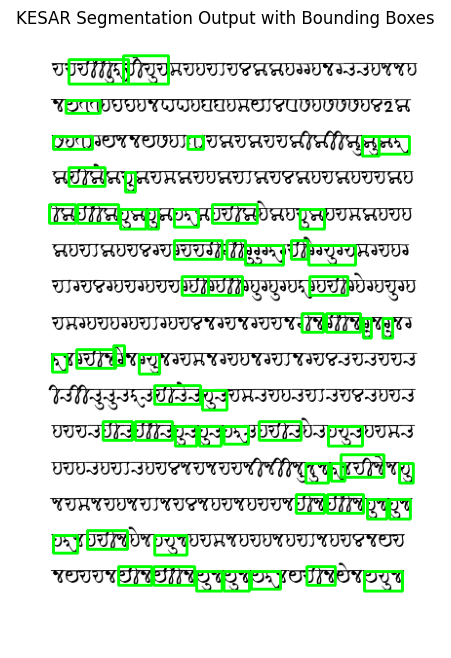

,x,y,width,height
0,40,177,27,19
1,43,331,15,18
2,44,107,40,13
3,44,517,25,18
4,57,70,35,13
5,60,28,61,25
6,60,139,37,19
7,68,326,40,19
8,69,177,42,19
9,79,512,41,19


In [18]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Simulate file path
image_path = "D:\dlcv project\dlcv.png"

# ---- KESAR Knowledge Base ----
MODI_CHAR_MIN_HEIGHT_RATIO = 0.02
MODI_CHAR_MAX_HEIGHT_RATIO = 0.4
MODI_CHAR_MIN_WIDTH_RATIO = 0.005
MODI_CHAR_MAX_WIDTH_RATIO = 0.15
SHIROREKHA_ROW_THRESHOLD = 0.7

def remove_shirorekha(binary_img):
    horizontal_sum = np.sum(binary_img == 255, axis=1)
    threshold = SHIROREKHA_ROW_THRESHOLD * np.max(horizontal_sum)
    shirorekha_removed = binary_img.copy()
    for row in range(len(horizontal_sum)):
        if horizontal_sum[row] > threshold:
            shirorekha_removed[row, :] = 0
    return shirorekha_removed

def apply_kesar_segmentation(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    no_shirorekha = remove_shirorekha(binary)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    cleaned = cv2.morphologyEx(no_shirorekha, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cleaned, connectivity=8)

    h_img, w_img = gray.shape
    bboxes = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        height_ratio = h / h_img
        width_ratio = w / w_img
        if (MODI_CHAR_MIN_HEIGHT_RATIO <= height_ratio <= MODI_CHAR_MAX_HEIGHT_RATIO and
            MODI_CHAR_MIN_WIDTH_RATIO <= width_ratio <= MODI_CHAR_MAX_WIDTH_RATIO):
            bboxes.append((x, y, w, h))
    bboxes = sorted(bboxes, key=lambda box: box[0])
    return img, bboxes

# Run on the sample image
original_img, bboxes = apply_kesar_segmentation(image_path)

# Draw bounding boxes
output_img = original_img.copy()
for (x, y, w, h) in bboxes:
    cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Show output image
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title("KESAR Segmentation Output with Bounding Boxes")
plt.axis("off")
plt.show()

# Create a DataFrame from the bounding boxes
df = pd.DataFrame(bboxes, columns=["x", "y", "width", "height"])
df  # Show the first few bounding boxes as output



In [19]:
import cv2
import numpy as np
import pandas as pd
import os

# Input/Output paths
INPUT_IMAGE = "D:/dlcv project/dlcv.png"
OUTPUT_CSV = "D:/dlcv project/bounding.csv"
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)

def remove_shirorekha(binary_img):
    """Remove horizontal line (shirorekha) using horizontal projection profile."""
    proj = np.sum(binary_img == 255, axis=1)
    threshold = 0.7 * np.max(proj)
    for i, val in enumerate(proj):
        if val > threshold:
            binary_img[i, :] = 0
    return binary_img

def kesar_segment(image_path):
    # Load and preprocess image
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Heuristic 1: Remove Shirorekha
    shirorekha_removed = remove_shirorekha(bin_img.copy())

    # Heuristic 2: Line segmentation (using horizontal projection)
    proj = np.sum(shirorekha_removed == 255, axis=1)
    lines = []
    in_line = False
    for i, val in enumerate(proj):
        if val > 0 and not in_line:
            start = i
            in_line = True
        elif val == 0 and in_line:
            end = i
            lines.append((start, end))
            in_line = False
    if in_line:
        lines.append((start, len(proj)))

    char_boxes = []
    for (top, bottom) in lines:
        line_img = shirorekha_removed[top:bottom, :]
        
        # Heuristic 3: Word gap estimation (using vertical projection)
        vertical_proj = np.sum(line_img == 255, axis=0)
        in_char = False
        for x in range(len(vertical_proj)):
            if vertical_proj[x] > 0 and not in_char:
                x_start = x
                in_char = True
            elif vertical_proj[x] == 0 and in_char:
                x_end = x
                if x_end - x_start > 3:  # character min width
                    char_boxes.append((x_start, top, x_end - x_start, bottom - top))
                in_char = False
        if in_char:
            char_boxes.append((x_start, top, len(vertical_proj) - x_start, bottom - top))

    return char_boxes, img

# Run segmentation
boxes, original_img = kesar_segment(INPUT_IMAGE)

# Save output
df = pd.DataFrame(boxes, columns=["x", "y", "width", "height"])
df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved {len(boxes)} character boxes to {OUTPUT_CSV}")

# (Optional) Visualize
for (x, y, w, h) in boxes:
    cv2.rectangle(original_img, (x, y), (x + w, y + h), (0, 0, 255), 1)
cv2.imshow("Character Segmentation", original_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


✅ Saved 442 character boxes to D:/dlcv project/bounding.csv


In [20]:
import cv2
import numpy as np
import pandas as pd
import os

# -------- CONFIG --------
INPUT_FOLDER = r"D:\dlcv project\images"
OUTPUT_CSV_FOLDER = r"D:\dlcv project\bounding_final"
os.makedirs(OUTPUT_CSV_FOLDER, exist_ok=True)

def remove_shirorekha(binary_img):
    """Heuristic: Remove Shirorekha using horizontal projection profile."""
    proj = np.sum(binary_img == 255, axis=1)
    threshold = 0.7 * np.max(proj)
    for i, val in enumerate(proj):
        if val > threshold:
            binary_img[i, :] = 0
    return binary_img

def kesar_segment_characters(image_path):
    # Load and preprocess
    img = cv2.imread(image_path)
    if img is None:
        print(f"⚠️ Could not load {image_path}")
        return []
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Remove Shirorekha
    shirorekha_removed = remove_shirorekha(bin_img.copy())

    # Line segmentation using horizontal projection
    proj = np.sum(shirorekha_removed == 255, axis=1)
    lines = []
    in_line = False
    for i, val in enumerate(proj):
        if val > 0 and not in_line:
            start = i
            in_line = True
        elif val == 0 and in_line:
            end = i
            lines.append((start, end))
            in_line = False
    if in_line:
        lines.append((start, len(proj)))

    char_boxes = []
    for (top, bottom) in lines:
        line_img = shirorekha_removed[top:bottom, :]

        # Character segmentation using vertical projection
        vertical_proj = np.sum(line_img == 255, axis=0)
        in_char = False
        for x in range(len(vertical_proj)):
            if vertical_proj[x] > 0 and not in_char:
                x_start = x
                in_char = True
            elif vertical_proj[x] == 0 and in_char:
                x_end = x
                if x_end - x_start > 3:
                    char_boxes.append((x_start, top, x_end - x_start, bottom - top))
                in_char = False
        if in_char:
            char_boxes.append((x_start, top, len(vertical_proj) - x_start, bottom - top))

    return char_boxes

# -------- BATCH PROCESSING --------
for filename in sorted(os.listdir(INPUT_FOLDER)):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_path = os.path.join(INPUT_FOLDER, filename)
        boxes = kesar_segment_characters(image_path)

        # Save CSV
        df = pd.DataFrame(boxes, columns=["x", "y", "width", "height"])
        base_name = os.path.splitext(filename)[0]
        csv_path = os.path.join(OUTPUT_CSV_FOLDER, f"{base_name}.csv")
        df.to_csv(csv_path, index=False)
        print(f"✅ Processed {filename} → {len(boxes)} characters")

print("🎉 All images processed and KESAR-based CSVs saved.")


✅ Processed dlcv_modi (1)_page-0001.jpg → 467 characters
✅ Processed dlcv_modi (1)_page-0002.jpg → 447 characters
✅ Processed dlcv_modi (1)_page-0003.jpg → 417 characters
✅ Processed dlcv_modi (1)_page-0004.jpg → 467 characters
✅ Processed dlcv_modi (1)_page-0005.jpg → 450 characters
✅ Processed dlcv_modi (1)_page-0006.jpg → 437 characters
✅ Processed dlcv_modi (1)_page-0007.jpg → 459 characters
✅ Processed dlcv_modi (1)_page-0008.jpg → 435 characters
✅ Processed dlcv_modi (1)_page-0009.jpg → 449 characters
✅ Processed dlcv_modi (1)_page-0010.jpg → 432 characters
✅ Processed dlcv_modi (1)_page-0011.jpg → 468 characters
✅ Processed dlcv_modi (1)_page-0012.jpg → 437 characters
✅ Processed dlcv_modi (1)_page-0013.jpg → 430 characters
✅ Processed dlcv_modi (1)_page-0014.jpg → 474 characters
✅ Processed dlcv_modi (1)_page-0015.jpg → 431 characters
✅ Processed dlcv_modi (1)_page-0016.jpg → 435 characters
✅ Processed dlcv_modi (1)_page-0017.jpg → 470 characters
✅ Processed dlcv_modi (1)_page-

In [21]:
import cv2
import numpy as np
import pandas as pd
import os

# Input/Output folders
INPUT_FOLDER = r"D:\dlcv project\images"
OUTPUT_CSV_FOLDER = r"D:\dlcv project\bounding_final"
os.makedirs(OUTPUT_CSV_FOLDER, exist_ok=True)

def remove_shirorekha(binary_img):
    """Remove horizontal line (shirorekha) using horizontal projection profile."""
    proj = np.sum(binary_img == 255, axis=1)
    threshold = 0.7 * np.max(proj)
    for i, val in enumerate(proj):
        if val > threshold:
            binary_img[i, :] = 0
    return binary_img

def kesar_segment(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Could not load image: {image_path}")
        return []

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Heuristic 1: Remove Shirorekha
    shirorekha_removed = remove_shirorekha(bin_img.copy())

    # Heuristic 2: Line segmentation
    proj = np.sum(shirorekha_removed == 255, axis=1)
    lines = []
    in_line = False
    for i, val in enumerate(proj):
        if val > 0 and not in_line:
            start = i
            in_line = True
        elif val == 0 and in_line:
            end = i
            lines.append((start, end))
            in_line = False
    if in_line:
        lines.append((start, len(proj)))

    char_boxes = []
    for (top, bottom) in lines:
        line_img = shirorekha_removed[top:bottom, :]
        vertical_proj = np.sum(line_img == 255, axis=0)
        in_char = False
        for x in range(len(vertical_proj)):
            if vertical_proj[x] > 0 and not in_char:
                x_start = x
                in_char = True
            elif vertical_proj[x] == 0 and in_char:
                x_end = x
                if x_end - x_start > 3:
                    char_boxes.append((x_start, top, x_end - x_start, bottom - top))
                in_char = False
        if in_char:
            char_boxes.append((x_start, top, len(vertical_proj) - x_start, bottom - top))

    return char_boxes

# ----------- Batch Processing ------------
for filename in sorted(os.listdir(INPUT_FOLDER)):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_path = os.path.join(INPUT_FOLDER, filename)
        output_csv = os.path.join(OUTPUT_CSV_FOLDER, f"{os.path.splitext(filename)[0]}.csv")

        boxes = kesar_segment(image_path)
        df = pd.DataFrame(boxes, columns=["x", "y", "width", "height"])
        df.to_csv(output_csv, index=False)
        print(f"✅ Processed: {filename} — {len(boxes)} characters")


✅ Processed: dlcv_modi (1)_page-0001.jpg — 467 characters
✅ Processed: dlcv_modi (1)_page-0002.jpg — 447 characters
✅ Processed: dlcv_modi (1)_page-0003.jpg — 417 characters
✅ Processed: dlcv_modi (1)_page-0004.jpg — 467 characters
✅ Processed: dlcv_modi (1)_page-0005.jpg — 450 characters
✅ Processed: dlcv_modi (1)_page-0006.jpg — 437 characters
✅ Processed: dlcv_modi (1)_page-0007.jpg — 459 characters
✅ Processed: dlcv_modi (1)_page-0008.jpg — 435 characters
✅ Processed: dlcv_modi (1)_page-0009.jpg — 449 characters
✅ Processed: dlcv_modi (1)_page-0010.jpg — 432 characters
✅ Processed: dlcv_modi (1)_page-0011.jpg — 468 characters
✅ Processed: dlcv_modi (1)_page-0012.jpg — 437 characters
✅ Processed: dlcv_modi (1)_page-0013.jpg — 430 characters
✅ Processed: dlcv_modi (1)_page-0014.jpg — 474 characters
✅ Processed: dlcv_modi (1)_page-0015.jpg — 431 characters
✅ Processed: dlcv_modi (1)_page-0016.jpg — 435 characters
✅ Processed: dlcv_modi (1)_page-0017.jpg — 470 characters
✅ Processed: d

In [24]:
import cv2
import numpy as np
import pandas as pd
import os

# Input/Output paths
INPUT_IMAGE = "D:\dlcv project\WhatsApp Image 2025-05-07 at 17.11.59 (2).jpeg"
OUTPUT_CSV = "D:/dlcv project/bounding1.csv"
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)

def remove_shirorekha(binary_img):
    """Remove horizontal line (shirorekha) using horizontal projection profile."""
    proj = np.sum(binary_img == 255, axis=1)
    threshold = 0.7 * np.max(proj)
    for i, val in enumerate(proj):
        if val > threshold:
            binary_img[i, :] = 0
    return binary_img

def kesar_segment(image_path):
    # Load and preprocess image
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Heuristic 1: Remove Shirorekha
    shirorekha_removed = remove_shirorekha(bin_img.copy())

    # Heuristic 2: Line segmentation (using horizontal projection)
    proj = np.sum(shirorekha_removed == 255, axis=1)
    lines = []
    in_line = False
    for i, val in enumerate(proj):
        if val > 0 and not in_line:
            start = i
            in_line = True
        elif val == 0 and in_line:
            end = i
            lines.append((start, end))
            in_line = False
    if in_line:
        lines.append((start, len(proj)))

    char_boxes = []
    for (top, bottom) in lines:
        line_img = shirorekha_removed[top:bottom, :]
        
        # Heuristic 3: Word gap estimation (using vertical projection)
        vertical_proj = np.sum(line_img == 255, axis=0)
        in_char = False
        for x in range(len(vertical_proj)):
            if vertical_proj[x] > 0 and not in_char:
                x_start = x
                in_char = True
            elif vertical_proj[x] == 0 and in_char:
                x_end = x
                if x_end - x_start > 3:  # character min width
                    char_boxes.append((x_start, top, x_end - x_start, bottom - top))
                in_char = False
        if in_char:
            char_boxes.append((x_start, top, len(vertical_proj) - x_start, bottom - top))

    return char_boxes, img

# Run segmentation
boxes, original_img = kesar_segment(INPUT_IMAGE)

# Save output
df = pd.DataFrame(boxes, columns=["x", "y", "width", "height"])
df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved {len(boxes)} character boxes to {OUTPUT_CSV}")

# (Optional) Visualize
for (x, y, w, h) in boxes:
    cv2.rectangle(original_img, (x, y), (x + w, y + h), (0, 0, 255), 1)
cv2.imshow("Character Segmentation", original_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ACER\AppData\Local\Temp\ipykernel_157128\3576498422.py:7: SyntaxWarning: invalid escape sequence '\d'
  INPUT_IMAGE = "D:\dlcv project\WhatsApp Image 2025-05-07 at 17.11.59 (2).jpeg"


✅ Saved 193 character boxes to D:/dlcv project/bounding1.csv


In [25]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import cv2
import numpy as np
import pandas as pd
import os
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models

# Input/Output folders
INPUT_FOLDER = r"D:\dlcv project\images"
OUTPUT_CSV_FOLDER = r"D:\dlcv project\boundingcnn"
OUTPUT_CROPS_FOLDER = r"D:\dlcv project\crops"
MODEL_DIR = r"D:\dlcv project\model"
os.makedirs(OUTPUT_CSV_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_CROPS_FOLDER, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

def remove_shirorekha(binary_img):
    """Remove horizontal line (shirorekha) using horizontal projection profile."""
    proj = np.sum(binary_img == 255, axis=1)
    threshold = 0.7 * np.max(proj)
    for i, val in enumerate(proj):
        if val > threshold:
            binary_img[i, :] = 0
    return binary_img

def kesar_segment(image_path, save_crops=True):
    """KESAR segmentation to detect character bounding boxes and save crops."""
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Could not load image: {image_path}")
        return [], [], img

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Heuristic 1: Remove Shirorekha
    shirorekha_removed = remove_shirorekha(bin_img.copy())

    # Heuristic 2: Line segmentation
    proj = np.sum(shirorekha_removed == 255, axis=1)
    lines = []
    in_line = False
    for i, val in enumerate(proj):
        if val > 0 and not in_line:
            start = i
            in_line = True
        elif val == 0 and in_line:
            end = i
            lines.append((start, end))
            in_line = False
    if in_line:
        lines.append((start, len(proj)))

    char_boxes = []
    char_crops = []
    for line_idx, (top, bottom) in enumerate(lines):
        line_img = shirorekha_removed[top:bottom, :]
        vertical_proj = np.sum(line_img == 255, axis=0)
        in_char = False
        for x in range(len(vertical_proj)):
            if vertical_proj[x] > 0 and not in_char:
                x_start = x
                in_char = True
            elif vertical_proj[x] == 0 and in_char:
                x_end = x
                if x_end - x_start > 3:
                    char_boxes.append((x_start, top, x_end - x_start, bottom - top, line_idx))
                    if save_crops:
                        crop = bin_img[top:bottom, x_start:x_end]
                        if crop.shape[0] > 10 and crop.shape[1] > 10:  # Filter tiny crops
                            char_crops.append((crop, (x_start, top, x_end - x_start, bottom - top, line_idx)))
                in_char = False
        if in_char:
            x_end = len(vertical_proj)
            if x_end - x_start > 3:
                char_boxes.append((x_start, top, x_end - x_start, bottom - top, line_idx))
                if save_crops:
                    crop = bin_img[top:bottom, x_start:x_end]
                    if crop.shape[0] > 10 and crop.shape[1] > 10:
                        char_crops.append((crop, (x_start, top, x_end - x_start, bottom - top, line_idx)))

    return char_boxes, char_crops, img

def build_cnn_verifier(input_shape=(32, 32, 1)):
    """Build a simple CNN model for verifying character crops."""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(2, activation='softmax')  # 2 classes: character or noise
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def preprocess_crop_for_cnn(crop, target_size=(32, 32)):
    """Preprocess crop for CNN input."""
    resized = cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)
    if len(resized.shape) == 2:
        resized = resized[:, :, np.newaxis]
    return resized / 255.0

def verify_crops_with_cnn(char_crops, model):
    """Use CNN to filter out false positives from crops."""
    verified_boxes = []
    verified_crops = []
    for crop, box_info in char_crops:
        preprocessed = preprocess_crop_for_cnn(crop)
        prediction = model.predict(np.array([preprocessed]), verbose=0)
        if np.argmax(prediction[0]) == 0:  # Assuming class 0 is 'character'
            verified_boxes.append(box_info[:4])  # x, y, width, height
            verified_crops.append((crop, box_info))
    return verified_boxes, verified_crops

def save_crops(char_crops, filename, output_dir=OUTPUT_CROPS_FOLDER):
    """Save character crops to disk."""
    base_name = os.path.splitext(filename)[0]
    crop_dir = os.path.join(output_dir, base_name)
    os.makedirs(crop_dir, exist_ok=True)
    for idx, (crop, box_info) in enumerate(char_crops):
        line_idx = box_info[4]
        crop_path = os.path.join(crop_dir, f"crop_l{line_idx}_c{idx}.png")
        cv2.imwrite(crop_path, crop)

def main():
    """Main function to process images, segment with KESAR, and verify with CNN."""
    # Placeholder: Load or build CNN model (train it separately with labeled data)
    cnn_model = build_cnn_verifier()
    model_path = os.path.join(MODEL_DIR, "cnn_verifier.h5")
    if os.path.exists(model_path):
        cnn_model.load_weights(model_path)
        print("✅ Loaded pre-trained CNN verifier model")
    else:
        print("⚠️ No pre-trained model found. Using untrained model (results may be inaccurate). Train the model first!")

    # Batch processing
    for filename in sorted(os.listdir(INPUT_FOLDER)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(INPUT_FOLDER, filename)
            output_csv = os.path.join(OUTPUT_CSV_FOLDER, f"{os.path.splitext(filename)[0]}.csv")

            # Step 1: KESAR segmentation to get boxes and crops
            boxes, crops, _ = kesar_segment(image_path)
            print(f"✅ Processed KESAR segmentation for {filename} - {len(boxes)} initial characters")

            # Step 2: Verify crops with CNN to filter false positives
            verified_boxes, verified_crops = verify_crops_with_cnn(crops, cnn_model)
            print(f"✅ CNN verification for {filename} - {len(verified_boxes)} verified characters")

            # Step 3: Save verified bounding boxes to CSV
            df = pd.DataFrame(verified_boxes, columns=["x", "y", "width", "height"])
            df.to_csv(output_csv, index=False)

            # Step 4: Save verified crops for inspection or further training
            save_crops(verified_crops, filename)

if __name__ == "__main__":
    main()


C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


⚠️ No pre-trained model found. Using untrained model (results may be inaccurate). Train the model first!
✅ Processed KESAR segmentation for dlcv_modi (1)_page-0001.jpg - 467 initial characters
✅ CNN verification for dlcv_modi (1)_page-0001.jpg - 356 verified characters
✅ Processed KESAR segmentation for dlcv_modi (1)_page-0002.jpg - 447 initial characters
✅ CNN verification for dlcv_modi (1)_page-0002.jpg - 370 verified characters
✅ Processed KESAR segmentation for dlcv_modi (1)_page-0003.jpg - 417 initial characters
✅ CNN verification for dlcv_modi (1)_page-0003.jpg - 360 verified characters
✅ Processed KESAR segmentation for dlcv_modi (1)_page-0004.jpg - 467 initial characters
✅ CNN verification for dlcv_modi (1)_page-0004.jpg - 363 verified characters
✅ Processed KESAR segmentation for dlcv_modi (1)_page-0005.jpg - 450 initial characters
✅ CNN verification for dlcv_modi (1)_page-0005.jpg - 384 verified characters
✅ Processed KESAR segmentation for dlcv_modi (1)_page-0006.jpg - 437 i

In [30]:
import cv2
import os
import numpy as np

# Define your paths
IMAGE_PATH = r"D:\dlcv project\images\dlcv_modi (1)_page-0069.jpg"  # <- Change this to the image you want
MODEL_PATH = r"D:\dlcv project\model\cnn_verifier.h5"

# === Reuse KESAR + CNN parts from your original code ===
# (Assuming you've already imported or pasted the kesar_segment, build_cnn_verifier, etc.)

# Load CNN model
cnn_model = build_cnn_verifier()
if os.path.exists(MODEL_PATH):
    cnn_model.load_weights(MODEL_PATH)
    print("✅ CNN model loaded.")
else:
    print("⚠️ Model not found. Using untrained model.")

# Run KESAR segmentation
boxes, crops, original_img = kesar_segment(IMAGE_PATH)

# Run verification
verified_boxes, _ = verify_crops_with_cnn(crops, cnn_model)

# Draw bounding boxes
img_with_boxes = original_img.copy()
for (x, y, w, h) in verified_boxes:
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Display image with bounding boxes
cv2.imshow("Verified Bounding Boxes", img_with_boxes)
cv2.waitKey(0)
cv2.destroyAllWindows()


⚠️ Model not found. Using untrained model.
